In [1]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pandas as pd
import numpy as np

#import copula functions
from pr_copula.main_copula_regression_conditional import fit_copula_cregression,predict_copula_cregression,predictive_resample_cregression,check_convergence_pr_cregression

from copula_mp import mp_density, mp_density_t_learner, mp_compliers

In [2]:
# Sommer & Zeger Vitamin A Study Dataset
# Create the dataset from contingency table
data_counts = [
    (0, 0, 0, 74),      # Assigned: No, Received: No, Outcome: Died
    (0, 0, 1, 11514),   # Assigned: No, Received: No, Outcome: Survived
    (1, 0, 0, 34),      # Assigned: Yes, Received: No, Outcome: Died
    (1, 0, 1, 2385),    # Assigned: Yes, Received: No, Outcome: Survived
    (1, 1, 0, 12),      # Assigned: Yes, Received: Yes, Outcome: Died
    (1, 1, 1, 9663)     # Assigned: Yes, Received: Yes, Outcome: Survived
]

Z_data = []
X_data = []
Y_data = []

for z, x, y, count in data_counts:
    Z_data.extend([z] * count)
    X_data.extend([x] * count)
    Y_data.extend([y] * count)

Z_data = np.array(Z_data)
X_data = np.array(X_data)
Y_data = np.array(Y_data)

print(f"Total observations: {len(Y_data)}")
print(f"Outcome distribution: {np.mean(Y_data):.4f}")
print(f"Treatment (X=1) rate: {np.mean(X_data):.4f}")
print(f"Instrument (Z=1) rate: {np.mean(Z_data):.4f}")

# Summary statistics by instrument assignment
print("\nSummary by Instrument Assignment:")
print(f"  Z=0: P(X=1|Z=0) = {np.mean(X_data[Z_data == 0]):.4f}")
print(f"  Z=1: P(X=1|Z=1) = {np.mean(X_data[Z_data == 1]):.4f}")
print(f"  Instrument effect on treatment: {np.mean(X_data[Z_data == 1]) - np.mean(X_data[Z_data == 0]):.4f}")

Total observations: 23682
Outcome distribution: 0.9949
Treatment (X=1) rate: 0.4085
Instrument (Z=1) rate: 0.5107

Summary by Instrument Assignment:
  Z=0: P(X=1|Z=0) = 0.0000
  Z=1: P(X=1|Z=1) = 0.8000
  Instrument effect on treatment: 0.8000


In [3]:
# Run mp_compliers with S-Learner approach
# Set up parameters
y_grid = np.array([0, 1])  # Binary outcome
B_post = 20   # Smaller: Number of posterior bootstrap samples
T_fwd = 20    # Smaller: Number of forward predictive samples

# For computational efficiency with large datasets, sample from the data
# Use a stratified sample to maintain the structure
np.random.seed(42)
sample_size = 500  # Much smaller sample for computational efficiency

# Stratified sampling to maintain group proportions
strata = Z_data * 2 + X_data
unique_strata = np.unique(strata)
indices = []
for s in unique_strata:
    strata_indices = np.where(strata == s)[0]
    n_strata = int(len(strata_indices) * sample_size / len(Y_data))
    n_strata = max(1, n_strata)  # Ensure at least 1 observation per stratum
    indices.extend(np.random.choice(strata_indices, size=n_strata, replace=False))

indices = np.array(indices)
Y_sample = Y_data[indices]
X_sample = X_data[indices]
Z_sample = Z_data[indices]

print(f"Running mp_compliers function on sample of {len(Y_sample)} observations...")
print(f"Parameters: B_post={B_post}, T_fwd={T_fwd}")
print("=" * 60)

results_compliers = mp_compliers(Y_sample, X_sample, Z_sample, y_grid, B_post, T_fwd, seed=42)

print("\n" + "=" * 60)
print("Interventional Density Results for Compliers:")
print("=" * 60)

Running mp_compliers function on sample of 499 observations...
Parameters: B_post=20, T_fwd=20
Compiling...
Compilation time: 2.711s
Optimizing...
Optimization time: 8.923s
Fitting...
Fit time: 0.111s
Optimised rho:  0.91120917
Optimised rho_x:  [0.8281949 0.8408534]
Prequential log-likelihood:  15.129674911499023

Response-type probabilities:
  p_A (Always-takers): 0.0000
  p_N (Never-takers): 0.2000
  p_C (Compliers): 0.8000
Predicting...
Prediction time: 0.657s
Predictive resampling...
Predictive resampling time: 1.353s

Interventional Density Results for Compliers:


In [4]:
# Display numerical results
print("\n1. Interventional Density p(Y(0) | Compliers):")
print("-" * 60)
for i, y_val in enumerate(y_grid):
    mean_val = results_compliers['y_0_given_C']['mean'][i]
    low_val = results_compliers['y_0_given_C']['low'][i]
    high_val = results_compliers['y_0_given_C']['high'][i]
    print(f"  Y={y_val}: {mean_val:.6f} [95% CI: {low_val:.6f}, {high_val:.6f}]")

print("\n2. Interventional Density p(Y(1) | Compliers):")
print("-" * 60)
for i, y_val in enumerate(y_grid):
    mean_val = results_compliers['y_1_given_C']['mean'][i]
    low_val = results_compliers['y_1_given_C']['low'][i]
    high_val = results_compliers['y_1_given_C']['high'][i]
    print(f"  Y={y_val}: {mean_val:.6f} [95% CI: {low_val:.6f}, {high_val:.6f}]")

# Compute treatment effect measures for compliers
print("\n3. Treatment Effect Estimates for Compliers:")
print("-" * 60)
prob_y1_when_treated = results_compliers['y_1_given_C']['mean'][1]
prob_y1_when_untreated = results_compliers['y_0_given_C']['mean'][1]

ATE_compliers = prob_y1_when_treated - prob_y1_when_untreated
print(f"  Difference in P(Y=1|Treated) - P(Y=1|Untreated): {ATE_compliers:.6f}")
print(f"  Interpretation: Treatment effect on probability of survival for compliers")


1. Interventional Density p(Y(0) | Compliers):
------------------------------------------------------------
  Y=0: 0.000000 [95% CI: 0.000000, 0.000000]
  Y=1: 1.000000 [95% CI: 1.000000, 1.000000]

2. Interventional Density p(Y(1) | Compliers):
------------------------------------------------------------
  Y=0: 0.000000 [95% CI: 0.000000, 0.000000]
  Y=1: 1.000000 [95% CI: 1.000000, 1.000000]

3. Treatment Effect Estimates for Compliers:
------------------------------------------------------------
  Difference in P(Y=1|Treated) - P(Y=1|Untreated): 0.000000
  Interpretation: Treatment effect on probability of survival for compliers


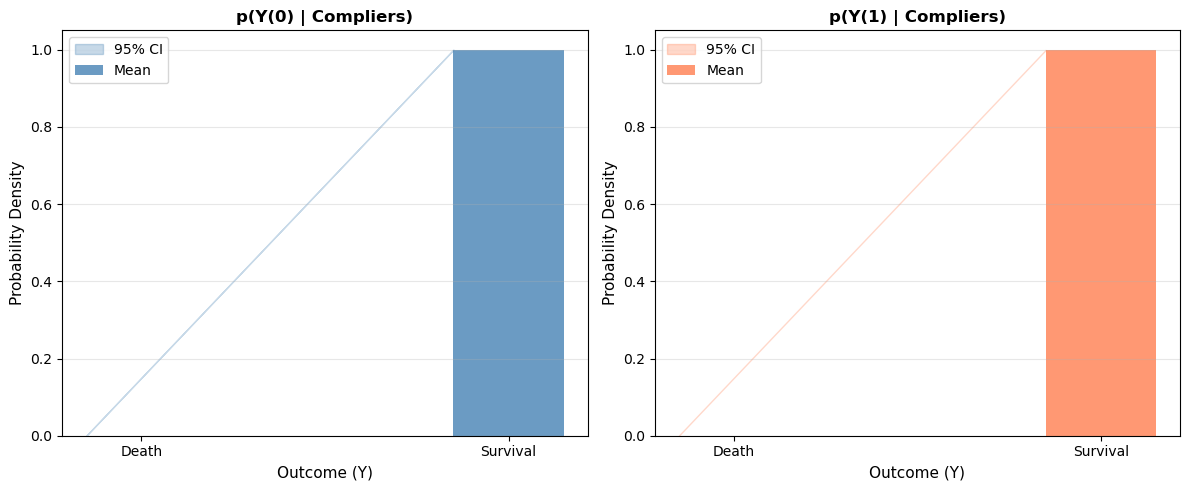


Visualization saved as 'Sommer_Zeger_Compliers_Densities.pdf'


In [ ]:
# Visualization of results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Density for Y(0) | Compliers
ax = axes[0]
y0_mean = results_compliers['y_0_given_C']['mean']
y0_low = results_compliers['y_0_given_C']['low']
y0_high = results_compliers['y_0_given_C']['high']

x_pos = np.arange(len(y_grid))
width = 0.3
ax.bar(x_pos, y0_mean, width=width, label='Mean', color='steelblue', alpha=0.8)
ax.fill_between(x_pos - width/2, y0_low, y0_high, alpha=0.3, color='steelblue', label='95% CI')
ax.set_xlabel('Outcome (Y)', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title('p(Y(0) | Compliers)', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(['Death', 'Survival'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2: Density for Y(1) | Compliers
ax = axes[1]
y1_mean = results_compliers['y_1_given_C']['mean']
y1_low = results_compliers['y_1_given_C']['low']
y1_high = results_compliers['y_1_given_C']['high']

x_pos = np.arange(len(y_grid))
ax.bar(x_pos, y1_mean, width=width, label='Mean', color='coral', alpha=0.8)
ax.fill_between(x_pos - width/2, y1_low, y1_high, alpha=0.3, color='coral', label='95% CI')
ax.set_xlabel('Outcome (Y)', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title('p(Y(1) | Compliers)', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(['Death', 'Survival'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Figures/Sommer_Zeger_Compliers_Densities.pdf', dpi=300, bbox_inches='tight')
plt.show()
